<a href="https://colab.research.google.com/github/rosagtr95/Data-Science-112-Final-Project/blob/main/Copy_of_datasci_project_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Horror Game Dictionary

This is the dictionary of games we will be using for this research, centered around the highest grossing horror games in the U.S. right now.
-Note: Game scripts are fairly difficult to find so this specialized horror game script was manually collected based on available (and accurate) transcriptions with open api for web scraping.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re


# Horror Game Scripts

games = {
    "RE2_remake": "https://game-scripts-wiki.blogspot.com/2019/07/resident-evil-2-2019-full-transcript.html",
    "RE3_remake": "https://game-scripts-wiki.blogspot.com/2020/04/resident-evil-3-2020-full-transcript.html",
    "RE4_remake": "https://game-scripts-wiki.blogspot.com/2023/05/resident-evil-4-remake-full-transcript.html",
    "RE6": "https://game-scripts-wiki.blogspot.com/2021/06/resident-evil-6-transcript.html",
    "RE7": "https://game-scripts-wiki.blogspot.com/2018/12/resident-evil-7-full-transcript.html",
    "RE8": "https://game-scripts-wiki.blogspot.com/2021/05/resident-evil-8-village-full-transcript.html",
    "Silent Hill": "https://gamefaqs.gamespot.com/ps/198641-silent-hill/faqs/27131",
    "Silent Hill 2": "https://gamefaqs.gamespot.com/ps2/437029-silent-hill-2/faqs/18290",
    "Silent Hill 3": "https://gamefaqs.gamespot.com/ps2/561292-silent-hill-3/faqs/23772",
    "Silent Hill 4": "https://gamefaqs.gamespot.com/ps2/919554-silent-hill-4-the-room/faqs/31470",
    "Fatal Frame": "https://game-scripts-wiki.blogspot.com/2019/03/fatal-frame-full-transcript.html",
    "The Last of Us Part I": "https://gamefaqs.gamespot.com/ps3/652686-the-last-of-us/faqs/68485",
    "The Last of Us Part II": "https://game-scripts-wiki.blogspot.com/2020/10/the-last-of-us-part-ii-full-transcript.html",
    "BioShock I": "https://game-scripts-wiki.blogspot.com/2022/01/bioshock-full-transcript.html",
    "BioShock II": "https://game-scripts-wiki.blogspot.com/2018/07/bioshock-2-full-transcript.html",
    "FNAF": "https://game-scripts-wiki.blogspot.com/2022/03/five-nights-at-freddys-security-breach.html",
    "Dead Space I": "https://game-scripts-wiki.blogspot.com/2021/07/dead-space-full-transcript.html",
    "Dead Space II": "https://game-scripts-wiki.blogspot.com/2022/08/dead-space-2-full-transcript.html",
    "Doom": "https://game-scripts-wiki.blogspot.com/2025/06/doom-dark-ages-full-transcript.html",
    "MediEvil": "https://game-scripts-wiki.blogspot.com/2022/01/medievil-1998-full-transcript.html",
    "At Dead of Night": "https://www.dawnborn.com/game-transcripts/at-dead-of-night-game-transcript/"
}

# Horror Game Script Web Scraping

Each script is scraped off the appropriate website (with a 2 second delay period to not overload the server or cause harm). The scraped text is then split into smaller "chuncks" of about 50 words to make our graph data more precise since we do not have thousands of whole game documents to analyize. This also works better for using NRC for emotion scoring later on.
(Horror game segments: 5673 means that we now have 5673 individual text lines to process and compare with news sources)


In [ ]:


def chunk_text(text, chunk_size=50):
    """Split text into chunks of roughly chunk_size words."""
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

# Scrape game scripts
game_segments = []

for game, url in games.items():
    print("Scraping:", game)
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")

    text = ""

    # Blogspot transcripts
    article = soup.find("div", class_="post-body")
    if article:
        text = article.get_text(separator=" ", strip=True)

    # GameFAQs transcripts
    if "gamefaqs" in url:
        faq = soup.find("pre")
        if faq:
            text = faq.get_text(separator=" ", strip=True)

    if text == "":
        text = soup.get_text(separator=" ", strip=True)

    # Split into 50-word chunks
    chunks = chunk_text(text, chunk_size=50)
    for chunk in chunks:
        game_segments.append({
            "media_type": "horror_game",
            "source": game,
            "text": chunk
        })

    time.sleep(2)  # ethical delay

df_game_segments = pd.DataFrame(game_segments)
print("Horror game segments:", len(df_game_segments))



Scraping: RE2_remake
Scraping: RE3_remake
Scraping: RE4_remake
Scraping: RE6
Scraping: RE7
Scraping: RE8
Scraping: Silent Hill
Scraping: Silent Hill 2
Scraping: Silent Hill 3
Scraping: Silent Hill 4
Scraping: Fatal Frame
Scraping: The Last of Us Part I
Scraping: The Last of Us Part II
Scraping: BioShock I
Scraping: BioShock II
Scraping: FNAF
Scraping: Dead Space I
Scraping: Dead Space II
Scraping: Doom
Scraping: MediEvil
Scraping: At Dead of Night
Horror game segments: 5673


In [ ]:
df_game_segments

,media_type,source,text
0,horror_game,RE2_remake,Note: I highly recommend you to read the origi...
1,horror_game,RE2_remake,"with my own eyes. Anchor: Oh, I believe you, b..."
2,horror_game,RE2_remake,"So I, I figured she was drunk. Anchor: Whoa, w..."
3,horror_game,RE2_remake,"her. You had to see her eyes, her nose… Her wh..."
4,horror_game,RE2_remake,"since of that night. Anchor: Alright, calm dow..."
...,...,...,...
5668,horror_game,At Dead of Night,"innovative use of live-action performances, an..."
5669,horror_game,At Dead of Night,"clues to unlock each ghost’s story, gradually ..."
5670,horror_game,At Dead of Night,studio: 📄 Contradiction: Spot the Liar! Our Re...
5671,horror_game,At Dead of Night,Chapter 6 – Hugo Punch All Clues Dialogues All...


# News API Webscraping

In [ ]:

# NewsAPI Top Headlines

api_key = "099177eddce541729bb6dfa03a2fea72"
sources = "cnn,fox-news,abc-news,cbs-news,nbc-news,the-new-york-times,usa-today,the-washington-post"

news_segments = []

for page in range(1, 31):  # 5 pages x 100 articles = ~500 articles
    url = (
      "https://newsapi.org/v2/everything?"
      "q=crime OR disaster OR attack OR shooting OR terror OR scared OR war OR danger"
      f"&sources={sources}"
      "&language=en"
      "&pageSize=100"
      f"&apiKey={api_key}"
)

    response = requests.get(url).json()

    if "articles" in response:
        for article in response["articles"]:
            text = (article.get("title") or "") + " " + (article.get("description") or "") + " " + (article.get("content") or "")
            chunks = chunk_text(text, chunk_size=50)
            for chunk in chunks:
                news_segments.append({
                    "media_type": "news",
                    "source": article["source"]["name"],
                    "text": chunk
                })

    time.sleep(2)  # ethical delay

df_news_segments = pd.DataFrame(news_segments)
print("News segments:", len(df_news_segments))



News segments: 5820


# Combining Databases

In [ ]:
# -------------------------
# 3. Combine Game + News
# -------------------------
df_all = pd.concat([df_game_segments, df_news_segments], ignore_index=True)

# Optional: Clean text for NLP
df_all["clean_text"] = df_all["text"].str.lower()
df_all["clean_text"] = df_all["clean_text"].apply(lambda x: re.sub(r"[^a-z\s]", "", x))

print("Total Segments (games + news):", len(df_all))
print(df_all.head())

Total Segments (games + news): 11493
    media_type      source                                               text  \
0  horror_game  RE2_remake  Note: I highly recommend you to read the origi...   
1  horror_game  RE2_remake  with my own eyes. Anchor: Oh, I believe you, b...   
2  horror_game  RE2_remake  So I, I figured she was drunk. Anchor: Whoa, w...   
3  horror_game  RE2_remake  her. You had to see her eyes, her nose… Her wh...   
4  horror_game  RE2_remake  since of that night. Anchor: Alright, calm dow...   

                                          clean_text  
0  note i highly recommend you to read the origin...  
1  with my own eyes anchor oh i believe you buddy...  
2  so i i figured she was drunk anchor whoa whoa ...  
3  her you had to see her eyes her nose her whole...  
4  since of that night anchor alright calm down b...  


# Tfidf Vectorizer: Extracting and Correcting 'Fear Words'

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Only use horror game segments
game_texts = df_all[df_all["media_type"]=="horror_game"]["clean_text"]

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)  # top 500 words
X = vectorizer.fit_transform(game_texts)

# Get the top words
tfidf_scores = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))

# Sort by TF-IDF
fear_vocab = sorted(tfidf_scores, key=tfidf_scores.get, reverse=True)[:100]  # top 100 fear-related words

print("Sample fear words:", fear_vocab[:20])

Sample fear words: ['ellie', 'leon', 'isaac', 'ethan', 'abby', 'im', 'just', 'dina', 'dont', 'like', 'way', 'right', 'know', 'finds', 'chris', 'got', 'come', 'radio', 'man', 'youre']


^ Our first issue was that there were too many names from main characters in our video games that had nothing to do with our main idea. To correct this, we manually removed the main character names from the Tfidf vectorizor and other filler words that created more noise in the data.


In [ ]:
#  character names from games
character_names = [
    'ellie','leon','isaac','ethan','abby','dina','chris','jake','sherry','ada',
    'jill','claire','alan','pierre','rebecca','marcus','franklin'
]

# Common stopwords / filler words
stop_words = [
    'im','just','dont','like','way','right','know','got','come','youre','i','he','she',
    'they','we','it','was','had','would','could','also','thats','thats','the','a','an'
]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

game_texts = df_all[df_all["media_type"]=="horror_game"]["clean_text"]

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(game_texts)

# All words sorted by TF-IDF score
tfidf_scores = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))
sorted_words = sorted(tfidf_scores, key=tfidf_scores.get, reverse=True)


fear_vocab = [w for w in sorted_words if w not in character_names + stop_words]

manual_fear_words = [
    "scream","blood","kill","death","dark","shadow","fear","terror","panic",
    "monster","haunt","scare","fight","run","escape","die","attack","danger",
    "shock","trap","creepy","horror","gun","knife","scream","screaming"
]

fear_vocab.extend(manual_fear_words)

fear_vocab = list(set(fear_vocab))  # remove duplicates

def fear_score(text, fear_vocab):
    words = text.split()
    return sum(1 for w in words if w in fear_vocab)

df_all['fear_score'] = df_all['clean_text'].apply(lambda x: fear_score(x, fear_vocab))

# 1. Count the total words in each document
df_all['word_count'] = df_all['clean_text'].apply(lambda x: len(str(x).split()))

# 2. Calculate the percentage (Fear Words / Total Words * 100)
# We add 1 to the denominator just in case there's an empty text to avoid a 'division by zero' error
df_all['fear_percentage'] = (df_all['fear_score'] / (df_all['word_count'] + 1)) * 100
# Check average fear scores
print(df_all.groupby('media_type')['fear_score'].mean())

media_type
horror_game    14.000560
news            4.685567
Name: fear_score, dtype: float64


# Individual Fear Scores for News Articles and Games

In [ ]:
df_all[df_all['media_type']=="news"].sort_values('fear_score', ascending=False)[['source','text','fear_score']]

KeyError: 'fear_score'

In [ ]:
df_all[df_all['media_type']=="horror_game"].sort_values('fear_score', ascending=False)

,media_type,source,text,clean_text,fear_score
4401,horror_game,FNAF,Map Bot opens the doors.] Map Bot: Free map. F...,map bot opens the doors map bot free map free ...,30
3247,horror_game,The Last of Us Part II,Isaac is? Woman: He was here a few minutes ago...,isaac is woman he was here a few minutes ago a...,29
3467,horror_game,The Last of Us Part II,Shut up. (killing) Don’t try anything. (killin...,shut up killing dont try anything killing shut...,28
527,horror_game,RE3_remake,Now fuck off. And don't say a word to anyone. ...,now fuck off and dont say a word to anyone car...,27
3242,horror_game,The Last of Us Part II,be out. Manny: She’ll be okay. She’ll be okay....,be out manny shell be okay shell be okay wlf s...,27
...,...,...,...,...,...
4242,horror_game,BioShock II,"a formula, waiting on us to solve for X.’ Inte...",a formula waiting on us to solve for x intelli...,1
1593,horror_game,RE6,exit of the diner.],exit of the diner,1
5672,horror_game,At Dead of Night,Dawnborn Contact AO3 FanFiction.net Neve | Pow...,dawnborn contact ao fanfictionnet neve powere...,1
5380,horror_game,Doom,of unfathomable dread where reality warps and ...,of unfathomable dread where reality warps and ...,0


# (Visualization 1) Fear Score Distributions

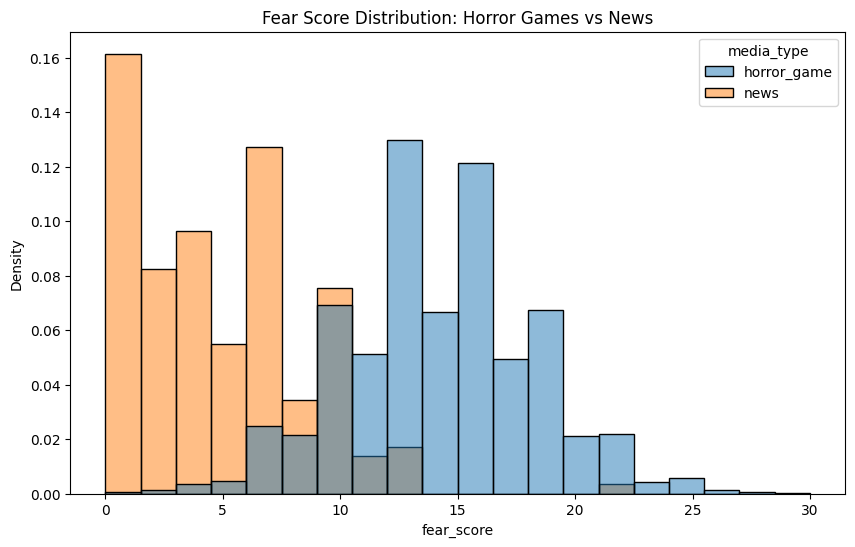

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df_all, x='fear_score', hue='media_type',
             bins=20, stat="density", common_norm=False, alpha=0.5)
plt.title("Fear Score Distribution: Horror Games vs News")
plt.show()

# (Visualization 2) PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Vectorize with noise reduction (min_df/max_df)
vectorizer = TfidfVectorizer(max_features=500, stop_words='english', min_df=2, max_df=0.9)
X_tfidf = vectorizer.fit_transform(df_all['clean_text'])

# 2. Scale the data (Crucial for better spreading in PCA)
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_tfidf)

# 3. Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled.toarray())

# 4. Assign back to dataframe
df_all['pca_x'] = X_pca[:, 0]
df_all['pca_y'] = X_pca[:, 1]


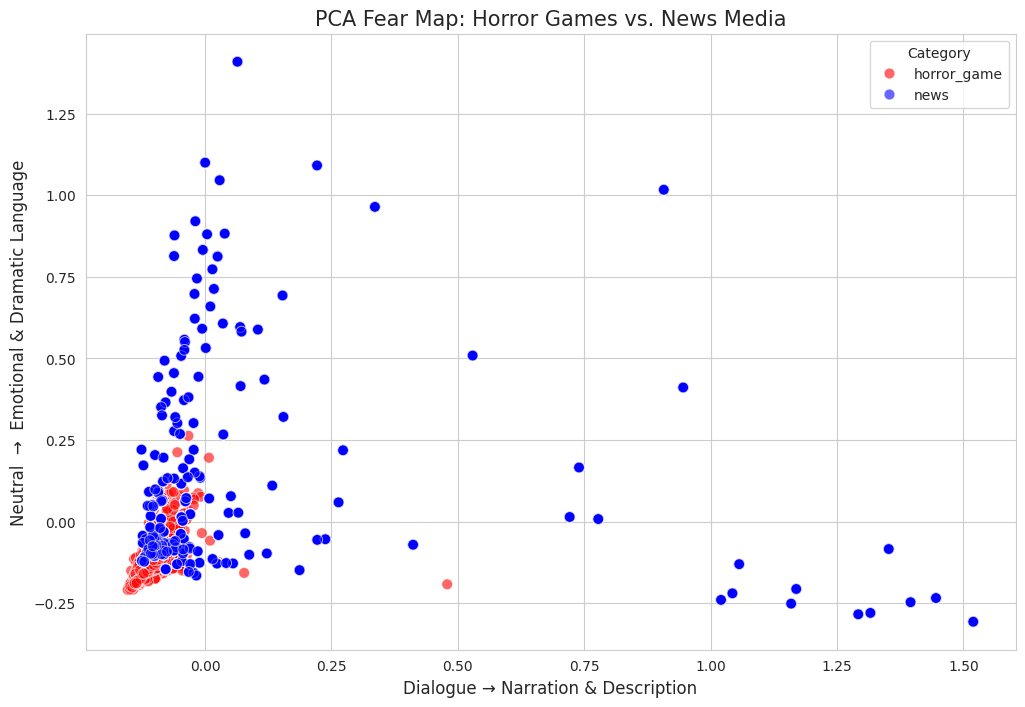

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the scatter plot
# We color by 'media_type' so Horror and News are distinct
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    hue='media_type',
    data=df_all,
    palette={'horror_game': 'red', 'news': 'blue'},
    alpha=0.6,
    s=60
)

# Add titles and labels
plt.title('PCA Fear Map: Horror Games vs. News Media', fontsize=15)
plt.xlabel('Dialogue → Narration & Description', fontsize=12)
plt.ylabel('Neutral  →  Emotional & Dramatic Language', fontsize=12)
plt.legend(title='Category')

# Show the plot
plt.show()

In [ ]:
import numpy as np

# Horror game centroid
game_centroid = df_all[df_all['media_type']=="horror_game"][['pca_x','pca_y']].mean().values

# Compute news source centroids
news_sources = df_all[df_all['media_type']=="news"]['source'].unique()
source_distances = []

for source in news_sources:
    source_data = df_all[(df_all['media_type']=="news") & (df_all['source']==source)][['pca_x','pca_y']]
    centroid = source_data.mean().values
    distance = np.linalg.norm(game_centroid - centroid)
    source_distances.append((source, distance))

# Sort by closest to horror games
source_distances.sort(key=lambda x: x[1])

print("News sources closest to horror games:")
for source, dist in source_distances:
    print(f"{source}: distance = {dist:.3f}")

News sources closest to horror games:
NBC News: distance = 0.230
Fox News: distance = 0.237
CNN: distance = 0.248
CBS News: distance = 0.272
USA Today: distance = 0.287


# Cosine Distances: News to Horror Games

This uses cosine similary, showing that actually CBS and Fox news use langauge that is most similar to horror game language-- which we can discuss


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute mean TF-IDF vectors
game_indices = df_all[df_all['media_type']=="horror_game"].index
news_df = df_all[df_all['media_type']=="news"]

# Convert to array to avoid np.matrix
game_vector = np.asarray(X_tfidf[game_indices].mean(axis=0))

source_similarities = []

for source in news_sources:
    source_indices = news_df[news_df['source']==source].index
    source_vector = np.asarray(X_tfidf[source_indices].mean(axis=0))
    sim = cosine_similarity(game_vector, source_vector)[0,0]
    source_similarities.append((source, sim))

# Sort by highest similarity
source_similarities.sort(key=lambda x: x[1], reverse=True)

print("News sources most similar to horror games (cosine similarity):")
for source, sim in source_similarities:
    print(f"{source}: similarity = {sim:.3f}")

News sources most similar to horror games (cosine similarity):
CBS News: similarity = 0.103
Fox News: similarity = 0.100
NBC News: similarity = 0.070
USA Today: similarity = 0.065
CNN: similarity = 0.061


# (Visualization 2.1) Annotated PCA

In [ ]:
# Take top 3 closest sources
top_sources = [s[0] for s in source_similarities[:3]]
print("Top 5 closest news sources:", top_sources)

Top 5 closest news sources: ['CBS News', 'Fox News', 'NBC News']


In [ ]:
# Get PCA centroids for top news sources
source_centroids = {}
for source in top_sources:
    source_data = df_all[(df_all['media_type']=="news") & (df_all['source']==source)][['pca_x','pca_y']]
    centroid = source_data.mean().values
    source_centroids[source] = centroid

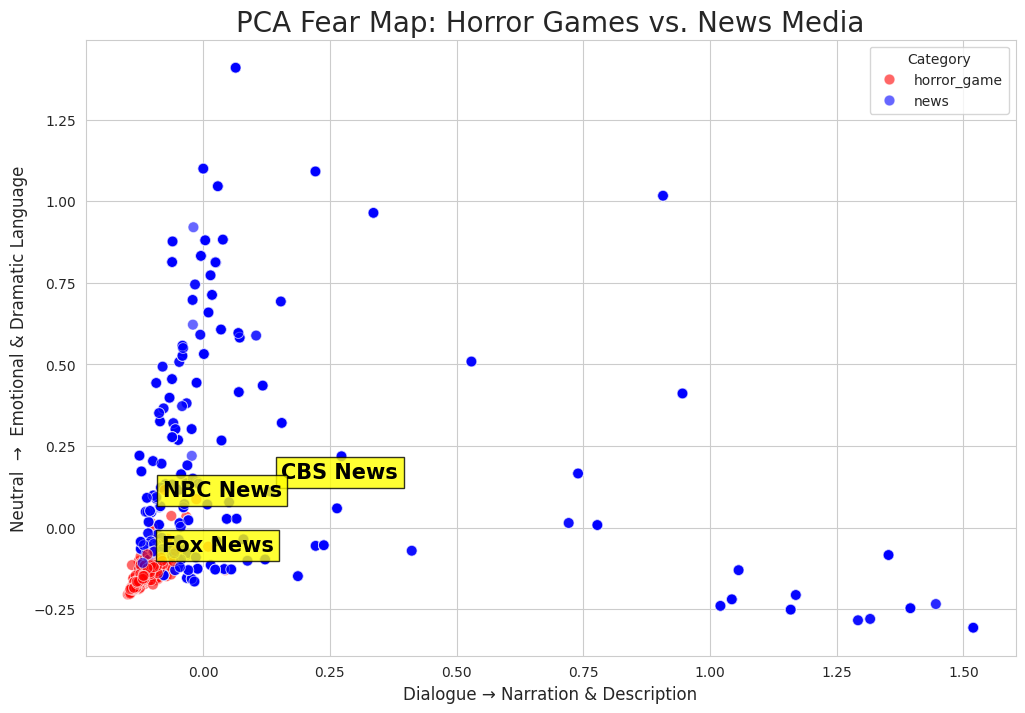

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

# Sample points for speed
sample_df = df_all.sample(2000, random_state=42)

sns.scatterplot(
    x='pca_x', y='pca_y',
    hue='media_type',
    data=sample_df,
    alpha=0.6,
    s=60,
    palette={"horror_game": "red", "news": "blue"}

)

# Label the top news sources
for source, centroid in source_centroids.items():
    plt.text(
        centroid[0], centroid[1], source,
        fontsize=15, fontweight='bold', color='black',
        bbox=dict(facecolor='yellow', alpha=0.8, edgecolor='black')
    )


plt.title('PCA Fear Map: Horror Games vs. News Media', fontsize=20)
plt.xlabel('Dialogue → Narration & Description', fontsize=12)
plt.ylabel('Neutral  →  Emotional & Dramatic Language', fontsize=12)
plt.legend(title='Category')



# NRC Lexicon 😭



This was QUITE HARD to figure out lol. Essentially, the python verson of the NRC lexicon is very out of date with current python software and had consistent bugs when trying to loop the lexicon through df_all data and couldn't handle the text size of each segment (even though they were only 50 words). Instead, I manually downloaded the lexicon to my computer from github (https://github.com/aditeyabaral/lok-sabha-election-twitter-analysis/blob/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt) and split the file into the list of words and their delegated emotion according to NRCLex. Then a mask was created for just the fear words (emotion rating = 1). The fear percentage calculated what percent of the text consisted of the NRClex associated fear words.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NRC-Emotion-Lexicon-Wordlevel-v0.92.txt to NRC-Emotion-Lexicon-Wordlevel-v0.92.txt


In [ ]:
nrc = pd.read_csv(
    "NRC-Emotion-Lexicon-Wordlevel-v0.92.txt",
    sep="\t",
    names=["word","emotion","association"]
)

nrc = nrc[nrc["association"] == 1]

fear_words = set(
    nrc[nrc["emotion"] == "fear"]["word"]
)

list(fear_words)[:20]


['sectarian',
 'armored',
 'combatant',
 'anarchist',
 'dominate',
 'despair',
 'inmate',
 'criminal',
 'cult',
 'destructive',
 'omen',
 'howl',
 'desecration',
 'auditor',
 'rebel',
 'grieve',
 'trepidation',
 'smite',
 'startle',
 'hell']

In [ ]:
def fear_score_nrc(text):

    words = text.split()

    score = sum(1 for w in words if w in fear_words)

    return score

In [ ]:
df_all["word_count"] = df_all["clean_text"].str.split().apply(len)

df_all["fear_percentage"] = (
    df_all["fear_score"] / (df_all["word_count"] + 1)
) * 100

In [ ]:
df_all.groupby("media_type")["fear_percentage"].mean()

,fear_percentage
media_type,
horror_game,2.850204
news,6.011124


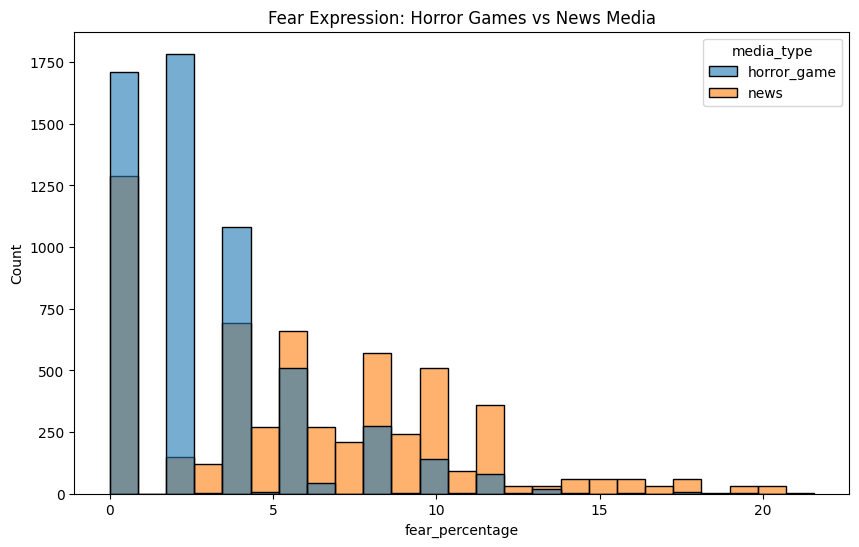

In [ ]:

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_all,
    x="fear_percentage",
    hue="media_type",
    bins=25,
    alpha=0.6
)

plt.title("Fear Expression: Horror Games vs News Media")
plt.show()

In [ ]:
df_all.groupby("media_type")[["fear_score","word_count"]].sum()

In [ ]:
fear_rate = totals["fear_score"] / totals["word_count"]

In [ ]:
from wordcloud import WordCloud

fear_words = nrc[nrc["association"] == 1]["word"].tolist()

fear_text = " ".join([
    word for word in df_all["clean_text"].str.split().explode()
    if word in fear_words
])

wc = WordCloud(width=800, height=400).generate(fear_text)

plt.imshow(wc)
plt.axis("off")
plt.title("Most Common Fear Words")

plt.show()

In [ ]:
df_all


,media_type,source,text,clean_text,fear_score,word_count,fear_percentage
0,horror_game,RE2_remake,Note: I highly recommend you to read the origi...,note i highly recommend you to read the origin...,0,50,0.000000
1,horror_game,RE2_remake,"with my own eyes. Anchor: Oh, I believe you, b...",with my own eyes anchor oh i believe you buddy...,0,49,0.000000
2,horror_game,RE2_remake,"So I, I figured she was drunk. Anchor: Whoa, w...",so i i figured she was drunk anchor whoa whoa ...,2,50,3.921569
3,horror_game,RE2_remake,"her. You had to see her eyes, her nose… Her wh...",her you had to see her eyes her nose her whole...,0,49,0.000000
4,horror_game,RE2_remake,"since of that night. Anchor: Alright, calm dow...",since of that night anchor alright calm down b...,1,50,1.960784
...,...,...,...,...,...,...,...
11488,news,NBC News,"speech this week was that the ""golden age of A...",speech this week was that the golden age of am...,0,14,0.000000
11489,news,CBS News,"Watch Live: Hegseth, Caine give Iran war updat...",watch live hegseth caine give iran war update ...,6,50,11.764706
11490,news,CBS News,"latest developments in the war with Iran, a da...",latest developments in the war with iran a day...,2,15,12.500000
11491,news,CBS News,"Trump tells CBS News ""the war is very complete...",trump tells cbs news the war is very complete ...,3,50,5.882353


In [ ]:
emotions = [
    "anger","anticipation","disgust","fear",
    "joy","sadness","surprise","trust"
]

emotion_cols = [f"{e}_percent" for e in emotions]

emotion_summary = df_all.groupby("media_type")[emotion_cols].mean()

NameError: name 'df_all' is not defined